In [1]:
## 建立網格 - 遮罩統計嚴格過濾版
import arcpy
import os
import math

# ==========================================
# 1. 參數設定 (加入自訂檔名設定)
# ==========================================
# --- 使用者自定義區 ---
file_prefix = "IL_P4"  # 自訂前綴
pixel_window = 512
# --------------------

arcpy.env.overwriteOutput = True
arcpy.CheckOutExtension("Spatial")
arcpy.CheckOutExtension("3D")
arcpy.env.addOutputsToMap = False 

input_dem = "IL_P4_2205_DEM_05mm_5x5m.tif"
target_gdb = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb"
TARGET_RES = 0.0005 # 0.5mm

# ==========================================
# 2. 取得 DEM 資訊與精度對齊
# ==========================================
# 強制轉為 Raster 物件以避免類型錯誤
raster_obj = arcpy.Raster(input_dem)
spatial_ref = raster_obj.spatialReference
arcpy.env.outputCoordinateSystem = spatial_ref
arcpy.env.snapRaster = input_dem 

extent = raster_obj.extent
grid_size = pixel_window * TARGET_RES

# 座標起點對齊 (使用原始 Extent 確保物理對齊)
origin_coord = f"{extent.XMin} {extent.YMin}"
y_axis_coord = f"{extent.XMin} {extent.YMin + 10}"

output_name = f"{file_prefix}_Grid_{pixel_window}"
fishnet_output = os.path.join(target_gdb, output_name)
zonal_table = os.path.join(target_gdb, "tmp_Zonal_Table")

print(f"--- 步驟 1: 建立網格並透過遮罩統計過濾 ---")

# ==========================================
# 3. 建立原始 Fishnet
# ==========================================
print("正在建立原始網格...")
arcpy.management.CreateFishnet(
    out_feature_class=fishnet_output,
    origin_coord=origin_coord,
    y_axis_coord=y_axis_coord,
    cell_width=grid_size,
    cell_height=grid_size,
    number_rows=0,
    number_columns=0,
    corner_coord=f"{extent.XMax} {extent.YMax}",
    geometry_type="POLYGON"
)

# ==========================================
# 4. 建立遮罩並進行像素計數
# ==========================================
print("正在建立有效像素遮罩 (1 = 有值, NoData = NaN)...")
# 邏輯：如果不是 Null，就給 1；否則就是 NoData
from arcpy.sa import IsNull, SetNull
dem_mask = SetNull(IsNull(raster_obj), 1)

print("正在統計每個網格內的像素總和...")
arcpy.management.AddField(fishnet_output, "ZoneID", "LONG")
arcpy.management.CalculateField(fishnet_output, "ZoneID", "!OID!", "PYTHON3")

# 使用 SUM 統計，這對整數遮罩非常精確且不會噴錯
arcpy.sa.ZonalStatisticsAsTable(
    in_zone_data=fishnet_output,
    zone_field="ZoneID",
    in_value_raster=dem_mask,
    out_table=zonal_table,
    ignore_nodata="DATA",
    statistics_type="SUM"
)

# ==========================================
# 5. 執行嚴格篩選 (排除邊緣與 NaN)
# ==========================================
print("執行嚴格篩選 (不完整的將被刪除)...")
arcpy.management.JoinField(fishnet_output, "ZoneID", zonal_table, "ZoneID", ["SUM"])

# 理論像素量 = 512 * 512 = 262144
expected_sum = pixel_window * pixel_window

fishnet_lyr = "fishnet_lyr"
arcpy.management.MakeFeatureLayer(fishnet_output, fishnet_lyr)

# 選擇符合 100% 滿載的網格
where_clause = f"SUM >= {expected_sum}"
arcpy.management.SelectLayerByAttribute(fishnet_lyr, "NEW_SELECTION", where_clause)

match_count = int(arcpy.management.GetCount(fishnet_lyr).getOutput(0))
total_count = int(arcpy.management.GetCount(fishnet_output).getOutput(0))

if match_count > 0:
    print(f"✅ 符合條件網格: {match_count} (排除 {total_count - match_count} 個)")
    # 反向選擇並刪除
    arcpy.management.SelectLayerByAttribute(fishnet_lyr, "SWITCH_SELECTION")
    arcpy.management.DeleteFeatures(fishnet_lyr)
    
    # 清理欄位
    arcpy.management.DeleteField(fishnet_output, ["ZoneID", "SUM"])
else:
    print("❌ 警告：沒有任何網格達到 100% 滿載！")
    print("可能原因：網格與像素未對齊，或 DEM 內部 NaN 點太多。")

# ==========================================
# 6. 加入 Contents 面板與清理
# ==========================================
if match_count > 0:
    arcpy.management.AddField(fishnet_output, "Grid_ID", "LONG")
    arcpy.management.CalculateField(fishnet_output, "Grid_ID", "!OID!", "PYTHON3")

if arcpy.Exists(zonal_table): arcpy.management.Delete(zonal_table)

try:
    aprx = arcpy.mp.ArcGISProject("CURRENT")
    if aprx.activeMap:
        for lyr in aprx.activeMap.listLayers(output_name):
            aprx.activeMap.removeLayer(lyr)
        aprx.activeMap.addDataFromPath(fishnet_output)
        print(f"✅ 圖層 {output_name} 已加入地圖。")
except:
    pass

print(f"✅ 步驟 1 任務完成！")

--- 步驟 1: 建立網格並透過遮罩統計過濾 ---
正在建立原始網格...
正在建立有效像素遮罩 (1 = 有值, NoData = NaN)...
正在統計每個網格內的像素總和...
執行嚴格篩選 (不完整的將被刪除)...
✅ 符合條件網格: 304 (排除 76 個)
✅ 圖層 IL_P4_Grid_512 已加入地圖。
✅ 步驟 1 任務完成！


In [19]:
import arcpy
import os
import numpy as np
import math
from arcpy.sa import *

# ==========================================
# 1. 參數與環境設定
# ==========================================
arcpy.env.overwriteOutput = True
arcpy.CheckOutExtension("Spatial")
arcpy.env.addOutputsToMap = False

input_dem = "OL_P1_2204_DEM_05mm_6x6m.tif"
target_gdb = r"D:\ArcGIS\Morpho_Spatial_Demography\MSD_Taiwan.gdb"

# 直接指定現有的網格圖層
target_grid_name = "DEM_Grid_512" 
target_grid = os.path.join(target_gdb, target_grid_name)

pixel_window = 512
TARGET_RES = 0.0005 
L0 = pixel_window * TARGET_RES 

# 算法選擇: "cosine", "area", "hvar"
METHOD = "area" 

# ==========================================
# 2. 執行運算
# ==========================================
print(f"--- 啟動快速指標計算: {target_grid_name} (方法: {METHOD}) ---")

# A. 計算 Rugosity 基礎柵格 (僅在需要時計算)
rug_raster = None
if METHOD == "cosine":
    print("正在生成 Cosine 坡度比率柵格...")
    # 這裡使用原生的 Raster Algebra，速度最快
    slope = Slope(input_dem, "DEGREE")
    # 1 / Cos(rad)，Con 用於處理 90 度極端值
    rug_raster = 1.0 / Cos(Con(slope > 85, 85, slope) * math.pi / 180)
elif METHOD == "area":
    # 這裡保留您的 Jenness 函數調用，但如果您只用 cosine，這段不會執行
    from __main__ import get_jenness_raster # 假設函數在同個檔案
    rug_raster = get_jenness_raster(input_dem)

# B. 區域統計 (Zonal Statistics)
# 直接對多邊形進行統計，ArcGIS 對此有內建優化
tmp_range_tab = os.path.join(target_gdb, "tmp_Rng_Stats")
tmp_rugo_tab = os.path.join(target_gdb, "tmp_Rug_Stats")

print("正在執行區域統計 (高度差)...")
ZonalStatisticsAsTable(target_grid, "Grid_ID", input_dem, tmp_range_tab, "DATA", "RANGE")

if rug_raster is not None:
    print("正在執行區域統計 (起伏度)...")
    ZonalStatisticsAsTable(target_grid, "Grid_ID", rug_raster, tmp_rugo_tab, "DATA", "MEAN")

# ==========================================
# 3. 數據寫入 (使用字典 lookup，速度遠快於 JoinField)
# ==========================================
print("正在讀取統計結果並寫入屬性表...")

# 讀取數據到記憶體字典
range_dict = {r[0]: r[1] for r in arcpy.da.SearchCursor(tmp_range_tab, ["Grid_ID", "RANGE"])}
rugo_dict = {r[0]: r[1] for r in arcpy.da.SearchCursor(tmp_rugo_tab, ["Grid_ID", "MEAN"])} if rug_raster is not None else {}

# 確保欄位存在
for f in [["Height_Range", "DOUBLE"], ["Rugosity", "DOUBLE"]]:
    if not arcpy.ListFields(target_grid, f[0]):
        arcpy.management.AddField(target_grid, f[0], f[1])

# 使用 UpdateCursor 一次性寫入所有數據
# 這比 JoinField + CalculateField 快 10 倍以上
with arcpy.da.UpdateCursor(target_grid, ["Grid_ID", "Height_Range", "Rugosity"]) as cursor:
    for row in cursor:
        gid = row[0]
        
        # 高度差數據
        h = range_dict.get(gid, -1)
        row[1] = h if h is not None else -1
        
        # 起伏度數據
        if h == -1:
            row[2] = -1
        elif METHOD == "hvar":
            row[2] = math.sqrt(((h**2) / (2 * (L0**2))) + 1)
        else:
            row[2] = rugo_dict.get(gid, -1)
            
        cursor.updateRow(row)

# ==========================================
# 4. 清理暫存
# ==========================================
print("清理暫存統計表...")
for t in [tmp_range_tab, tmp_rugo_tab]:
    if arcpy.Exists(t):
        arcpy.management.Delete(t)

# 釋放大型柵格物件
if rug_raster is not None:
    del rug_raster

print("-" * 30)
print(f"✅ 計算完成！")
print("-" * 30)

--- 啟動快速指標計算: DEM_Grid_512 (方法: area) ---
正在準備 Jenness 面積比率圖層 (NumPy 加速)...
正在執行區域統計 (高度差)...
正在執行區域統計 (起伏度)...
正在讀取統計結果並寫入屬性表...
清理暫存統計表...
------------------------------
✅ 計算完成！
------------------------------


--- 開始計算 (模式: mean_of_logs, 網格大小: 512px) ---
進度：已處理 100 個區塊...
進度：已處理 200 個區塊...
進度：已處理 300 個區塊...
✅ 計算完成！


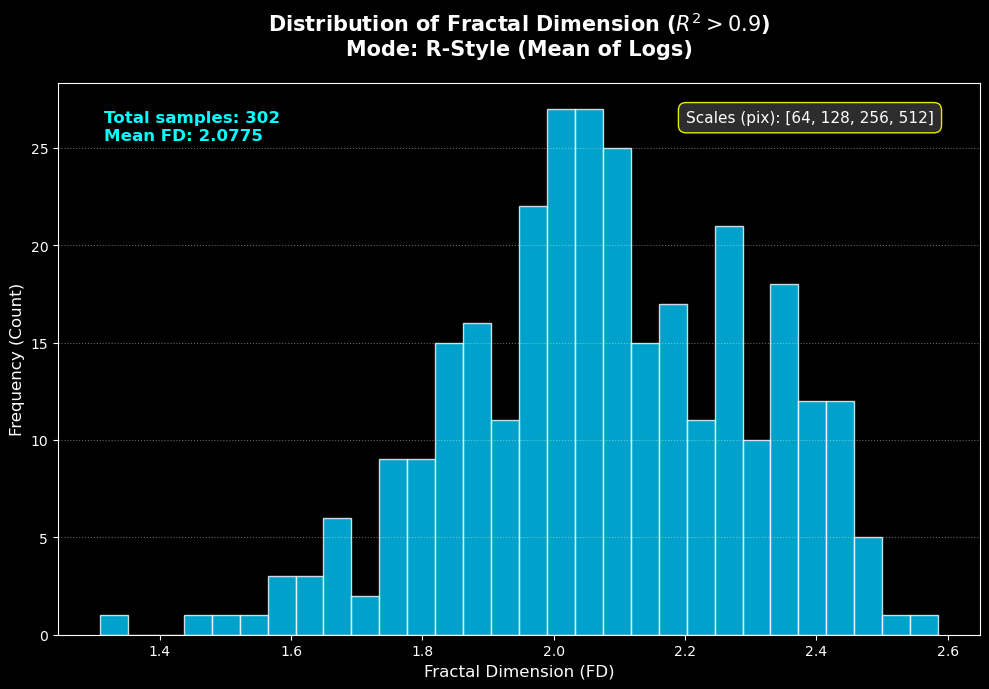

✅ 所有作業已完成。


In [2]:
import arcpy
import os
import numpy as np
import matplotlib.pyplot as plt
from arcpy.sa import *

# ==========================================
# 1. 參數與環境設定
# ==========================================
arcpy.env.overwriteOutput = True
arcpy.CheckOutExtension("Spatial")

# 設定背景風格為深色
plt.style.use('dark_background')

# 設置輸入資料與網格
input_dem = "IL_P4_2205_DEM_05mm_5x5m.tif" 
grid_layer = "IL_P4_Grid_512" 
TARGET_RES = 0.0005  # 0.5mm

# 【修改點】：在此設定你的網格像素大小 (例如 2048 或 512)
GRID_SIZE_PIX = 512

# 【模式切換】
CALC_MODE = "mean_of_logs" 
scales_pix = [64, 128, 256, 512]

# ==========================================
# 2. 定義核心 FD 函數 (保持不變)
# ==========================================
def get_fd_custom(sub_matrix, scales_list, cell_size, mode="mean_of_logs"):
    log_l = []
    log_h = []
    for s in scales_list:
        rows, cols = sub_matrix.shape
        try:
            r_max, c_max = (rows // s) * s, (cols // s) * s
            temp_view = sub_matrix[:r_max, :c_max].reshape(r_max // s, s, c_max // s, s)
            ranges = np.nanmax(temp_view, axis=(1, 3)) - np.nanmin(temp_view, axis=(1, 3))
            valid_ranges = ranges[ranges > 0]
            if len(valid_ranges) > 0:
                if mode == "mean_of_logs":
                    avg_val = np.nanmean(np.log10(valid_ranges))
                else:
                    avg_val = np.log10(np.nanmean(valid_ranges))
                log_l.append(np.log10(s * cell_size))
                log_h.append(avg_val)
        except:
            continue
    if len(log_l) < 3: return -1, 0
    coeffs, residuals, _, _, _ = np.polyfit(log_l, log_h, 1, full=True)
    slope = coeffs[0]
    y_mean = np.mean(log_h)
    ss_tot = np.sum((np.array(log_h) - y_mean)**2)
    r2 = 1 - (residuals[0] / ss_tot) if len(residuals) > 0 and ss_tot != 0 else 0
    return (3 - slope), r2

# ==========================================
# 3. 執行更新與計算
# ==========================================
print(f"--- 開始計算 (模式: {CALC_MODE}, 網格大小: {GRID_SIZE_PIX}px) ---")

# 檢查欄位
for f_name in ["Fractal_Dim", "FD_R2"]:
    if not arcpy.ListFields(grid_layer, f_name):
        arcpy.management.AddField(grid_layer, f_name, "DOUBLE")

raster_obj = arcpy.Raster(input_dem)
dem_array = arcpy.RasterToNumPyArray(raster_obj, nodata_to_value=np.nan)
dem_extent = raster_obj.extent

with arcpy.da.UpdateCursor(grid_layer, ["SHAPE@", "Fractal_Dim", "FD_R2"]) as cursor:
    count = 0
    for row in cursor:
        ext = row[0].extent
        c_start = int(round((ext.XMin - dem_extent.XMin) / TARGET_RES))
        r_start = int(round((dem_extent.YMax - ext.YMax) / TARGET_RES))
        
        # 【關鍵修改】：將原本固定的 512 替換為變數 GRID_SIZE_PIX
        sub_array = dem_array[r_start:r_start + GRID_SIZE_PIX, c_start:c_start + GRID_SIZE_PIX]
        
        if sub_array.size > 0 and np.count_nonzero(~np.isnan(sub_array)) > (sub_array.size * 0.5):
            fd_val, r2_val = get_fd_custom(sub_array, scales_pix, TARGET_RES, mode=CALC_MODE)
            row[1], row[2] = round(fd_val, 6), round(r2_val, 6)
        else:
            row[1], row[2] = -1, 0
        cursor.updateRow(row)
        count += 1
        if count % 100 == 0: print(f"進度：已處理 {count} 個區塊...")

print(f"✅ 計算完成！")

# ==========================================
# 4. 提取數據並繪製直方圖 (優化顏色版)
# ==========================================
fd_values = []
with arcpy.da.SearchCursor(grid_layer, ["Fractal_Dim", "FD_R2"]) as cursor:
    for row in cursor:
        if row[1] > 0.9 and row[0] > 0:
            fd_values.append(row[0])

if not fd_values:
    print("找不到符合 R2 > 0.9 的數據，無法繪圖。")
else:
    plt.figure(figsize=(10, 7))
    
    # 直方圖顏色：亮天藍色，邊緣白色
    plt.hist(fd_values, bins=30, color='#00CCFF', edgecolor='white', alpha=0.8)

    scales_str = ", ".join(map(str, scales_pix))
    mode_display = "R-Style (Mean of Logs)" if CALC_MODE == "mean_of_logs" else "Py-Style (Log of Mean)"
    
    # 標題：亮白色
    plt.title(f"Distribution of Fractal Dimension ($R^2 > 0.9$)\nMode: {mode_display}", 
              fontsize=15, fontweight='bold', color='white', pad=20)
    
    # 右上角標註方框：深灰底、白字、黃邊框
    plt.annotate(f"Scales (pix): [{scales_str}]", 
                 xy=(0.95, 0.95), xycoords='axes fraction', 
                 ha='right', va='top', fontsize=11, color='white',
                 bbox=dict(boxstyle="round,pad=0.5", fc="#333333", ec="#FFFF00", alpha=0.9))

    # 左上角統計文字：亮青色 (Cyan)
    plt.text(0.05, 0.95, f"Total samples: {len(fd_values)}\nMean FD: {np.mean(fd_values):.4f}", 
             transform=plt.gca().transAxes, ha='left', va='top', fontsize=12, 
             color='#00FFFF', fontweight='bold')

    # 座標軸與網格
    plt.xlabel("Fractal Dimension (FD)", fontsize=12, color='white')
    plt.ylabel("Frequency (Count)", fontsize=12, color='white')
    plt.grid(axis='y', linestyle=':', alpha=0.4, color='white')
    
    plt.tight_layout()
    plt.show()

print("✅ 所有作業已完成。")

In [2]:
import arcpy
import os

# 1. 設定參數
input_dem = "OL_P1_2204_DEM_05mm_6x6m.tif" # 原始 DEM
grid_layer = "DEM_Grid_2048"                  # 網格圖層
output_folder = r"C:\Users\keelu\Downloads"      # 輸出的資料夾路徑 (請修改此處)
target_ids = [20, 14]                   # 請替換成你想驗算的三個 Grid_ID

# 建立輸出資料夾（如果不存在）
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# 2. 遍歷指定的 ID 並匯出
print(f"開始匯出 Grid_ID: {target_ids} 的 DEM...")

for gid in target_ids:
    # 使用 SQL 語法篩選特定的 Grid_ID
    where_clause = f"Grid_ID = {gid}"
    
    # 使用 SearchCursor 取得該矩形的範圍 (Extent)
    with arcpy.da.SearchCursor(grid_layer, ["SHAPE@"], where_clause=where_clause) as cursor:
        found = False
        for row in cursor:
            found = True
            poly = row[0]
            ext = poly.extent
            
            # 定義輸出檔名，包含 Grid_ID
            out_name = f"DEM_Grid_{gid}.tif"
            out_path = os.path.join(output_folder, out_name)
            
            # 執行 Clip 工具
            # rectangle 參數格式為 "XMin YMin XMax YMax"
            rect = f"{ext.XMin} {ext.YMin} {ext.XMax} {ext.YMax}"
            
            arcpy.management.Clip(
                in_raster=input_dem,
                rectangle=rect,
                out_raster=out_path,
                in_template_dataset=poly, # 使用該多邊形作為裁切模板
                nodata_value="-9999",
                clipping_geometry="NONE", # 因為我們本來就是矩形，選 NONE 即可
                maintain_clipping_extent="MAINTAIN_EXTENT"
            )
            
            print(f"已匯出: {out_name}")
            
        if not found:
            print(f"找不到 Grid_ID 為 {gid} 的矩形，請檢查 ID 是否正確。")

print("所有指定檔案已匯出完成。")

開始匯出 Grid_ID: [20, 14] 的 DEM...
已匯出: DEM_Grid_20.tif
已匯出: DEM_Grid_14.tif
所有指定檔案已匯出完成。


------------------------------
【地形指標 3D 統計報告】

$Correlation_Matrix
        H       R       D
H  1.0000  0.7590 -0.6151
R  0.7590  1.0000 -0.1897
D -0.6151 -0.1897  1.0000

$Multiple_R_Squared (H & R explain D)
[1] 0.559571

$Regression_Formula
D = 2.2313 + (-0.7852 * H) + (0.0579 * R)
------------------------------


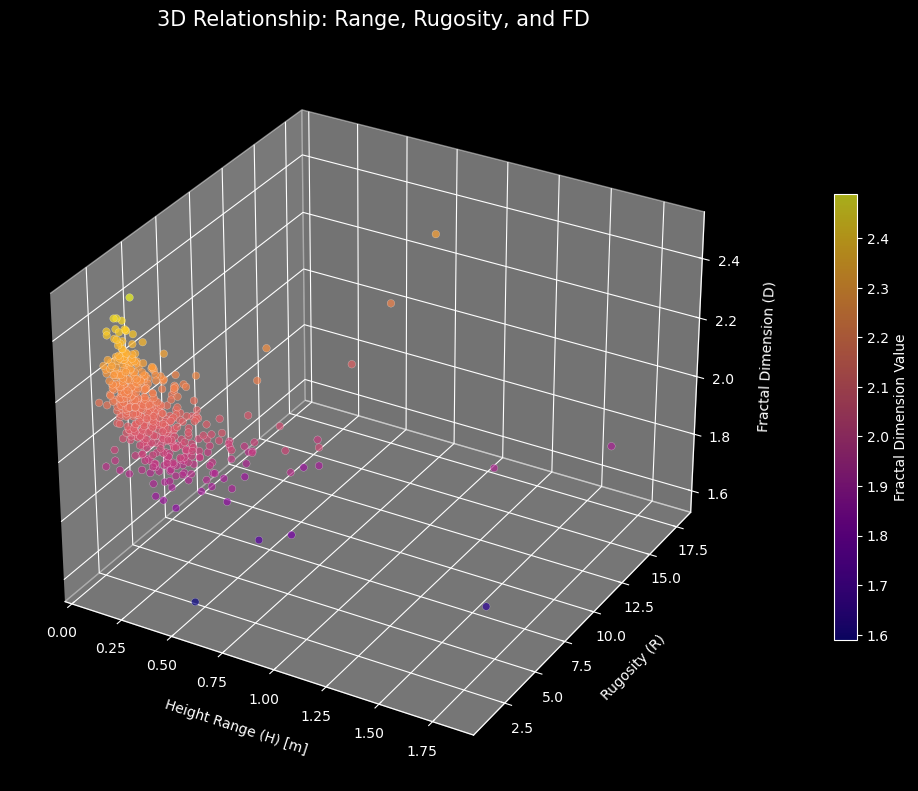

In [3]:
import arcpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 修正後的導入路徑

# 1. 設定環境
plt.style.use('dark_background')
grid_layer = "DEM_Grid_512"
# H=Height_Range, R=Rugosity, D=Fractal_Dim
fields = ["Height_Range", "Rugosity", "Fractal_Dim", "FD_R2"]

# 2. 提取數據 (篩選有效值)
data = []
with arcpy.da.SearchCursor(grid_layer, fields) as cursor:
    for row in cursor:
        # 排除無效值與 R2 過低的點
        if row[0] > 0 and row[2] > 0 and row[3] > 0.9:
            data.append(row[:3])

df = pd.DataFrame(data, columns=['H', 'R', 'D'])

if df.empty:
    print("數據量不足，請檢查篩選條件。")
else:
    # 3. 計算相關係數 (Pearson)
    corr_matrix = df.corr()
    
    # 4. 計算多元線性回歸 $R^2$ (使用 NumPy 矩陣運算代替 sklearn)
    # y = b0 + b1*H + b2*R
    Y = df['D'].values
    X = df[['H', 'R']].values
    X_matrix = np.column_stack([np.ones(X.shape[0]), X]) # 加入截距項
    
    # 使用最小平方法解係數: (X^T * X)^-1 * X^T * Y
    coeffs, residuals, rank, s = np.linalg.lstsq(X_matrix, Y, rcond=None)
    
    # 計算 R-squared
    ss_res = residuals[0] if len(residuals) > 0 else np.sum((Y - X_matrix @ coeffs)**2)
    ss_tot = np.sum((Y - np.mean(Y))**2)
    r_squared = 1 - (ss_res / ss_tot)

    # 5. 印出結果 (R Style)
    print("-" * 30)
    print("【地形指標 3D 統計報告】")
    print("\n$Correlation_Matrix")
    print(corr_matrix.round(4).to_string())
    
    print(f"\n$Multiple_R_Squared (H & R explain D)")
    print(f"[1] {r_squared:.6f}")
    
    print("\n$Regression_Formula")
    print(f"D = {coeffs[0]:.4f} + ({coeffs[1]:.4f} * H) + ({coeffs[2]:.4f} * R)")
    print("-" * 30)

    # 6. 繪製 3D 散佈圖
    fig = plt.figure(figsize=(10, 8))
    # 較新版本的 matplotlib 直接使用 projection='3d' 即可
    ax = fig.add_subplot(111, projection='3d')
    
    # 繪點，顏色隨 D (分形維度) 變化
    sc = ax.scatter(df['H'], df['R'], df['D'], 
                    c=df['D'], cmap='plasma', 
                    alpha=0.7, s=30, edgecolors='w', linewidth=0.2)
    
    ax.set_xlabel('Height Range (H) [m]', labelpad=10)
    ax.set_ylabel('Rugosity (R)', labelpad=10)
    ax.set_zlabel('Fractal Dimension (D)', labelpad=10)
    plt.title("3D Relationship: Range, Rugosity, and FD", fontsize=15, pad=20)
    
    # 加上顏色條
    cb = plt.colorbar(sc, pad=0.1, shrink=0.6)
    cb.set_label('Fractal Dimension Value')
    
    plt.tight_layout()
    plt.show()

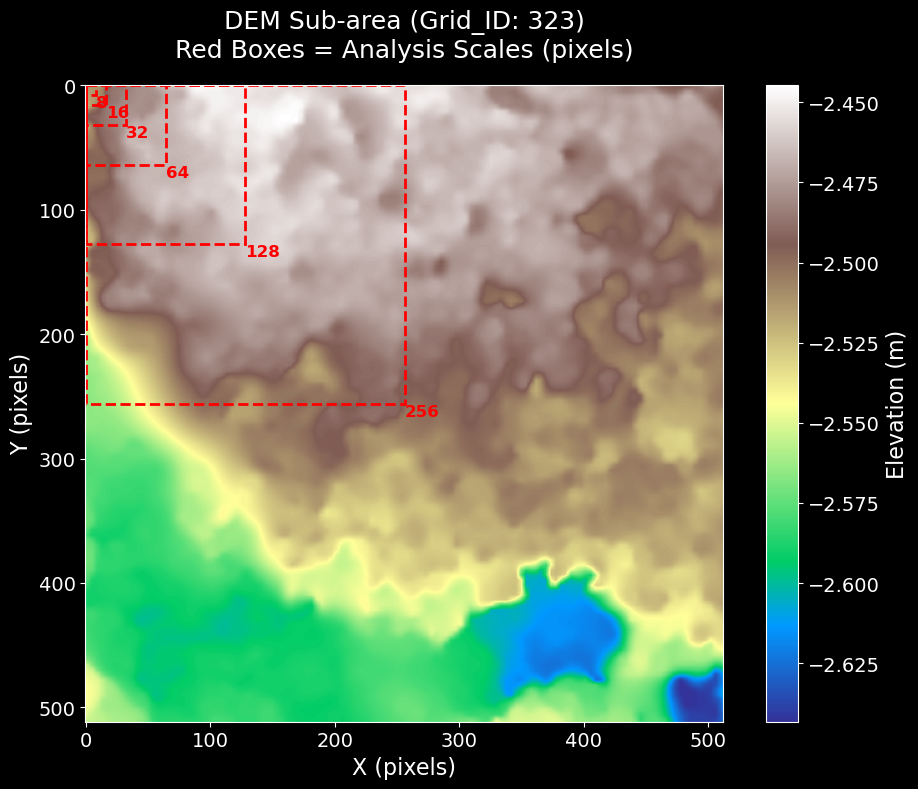

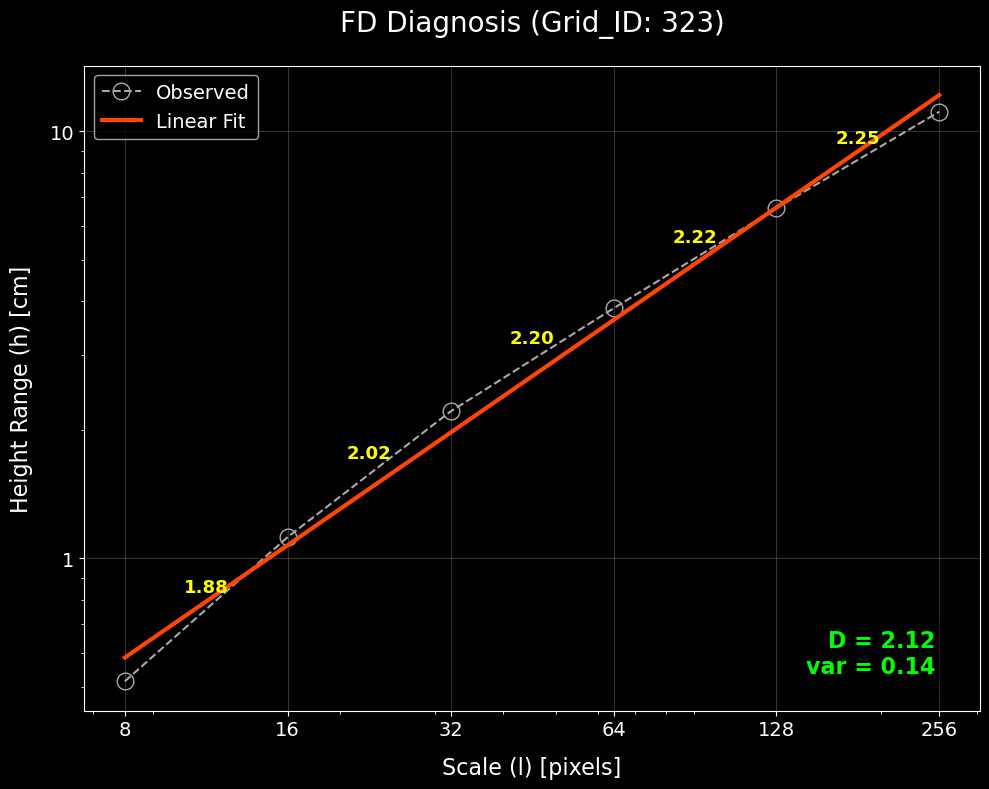

In [9]:
import arcpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
from matplotlib.patches import Rectangle  # 新增：用於畫框框

# 1. 基本設定
plt.style.use('dark_background') 
input_dem = "OL_P1_2204_DEM_05mm_6x6m.tif"
grid_layer = "DEM_Grid_512" 
target_id = 323 
scales_pix = [8, 16, 32, 64, 128, 256] 

# 【修改點 1】：設定網格大小
grid_px_size = 512

# 2. 數據獲取
desc = arcpy.Describe(input_dem)
cell_size = desc.meanCellWidth 
dem_extent = desc.extent
raster_obj = arcpy.Raster(input_dem)
dem_array = arcpy.RasterToNumPyArray(raster_obj, nodata_to_value=np.nan)

# 3. 提取指定 Grid_ID 的區域
where = f"Grid_ID = {target_id}"
with arcpy.da.SearchCursor(grid_layer, ["SHAPE@"], where_clause=where) as cursor:
    row = next(cursor, None)
    if not row: raise ValueError(f"找不到 ID: {target_id}")
    ext = row[0].extent

c_start = int(round((ext.XMin - dem_extent.XMin) / cell_size))
r_start = int(round((dem_extent.YMax - ext.YMax) / cell_size))
sub_array = dem_array[r_start:r_start + grid_px_size, c_start:c_start + grid_px_size]

# 4. 計算 HVAR 數據
l_m = np.array(scales_pix) * cell_size 
log_h = [] 
for s in scales_pix:
    r_max, c_max = (grid_px_size // s) * s, (grid_px_size // s) * s
    temp_view = sub_array[:r_max, :c_max].reshape(r_max // s, s, c_max // s, s)
    ranges = np.nanmax(temp_view, axis=(1, 3)) - np.nanmin(temp_view, axis=(1, 3))
    valid_ranges = ranges[ranges > 0]
    if len(valid_ranges) > 0:
        log_h.append(np.nanmean(np.log10(valid_ranges)))
    else:
        log_h.append(np.nan)

log_h = np.array(log_h)
log_l = np.log10(l_m)
h_m = 10**log_h

# 5. 計算指標
mask = ~np.isnan(log_h)
coeffs = np.polyfit(log_l[mask], log_h[mask], 1)
total_fd = 3 - coeffs[0]
d_vec = 3 - (np.diff(log_h) / np.diff(log_l))
var_val = np.std(d_vec)

# ---------------------------------------------------------
# 新增圖表：DEM 視覺化與尺度框框
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
plt.imshow(sub_array, cmap='terrain', origin='upper')
cbar = plt.colorbar(label='Elevation (m)')
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Elevation (m)', size=16)

ax_dem = plt.gca()

# 繪製不同尺度的紅色框框 (從左上角 0,0 開始)
for s in scales_pix:
    rect = Rectangle((0, 0), s, s, linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
    ax_dem.add_patch(rect)
    # 在框框邊緣標註 scale 大小
    plt.text(s, s, f"{s}", color='red', fontsize=12, fontweight='bold', ha='left', va='top')

plt.title(f"DEM Sub-area (Grid_ID: {target_id})\nRed Boxes = Analysis Scales (pixels)", fontsize=18, pad=20)
plt.xlabel("X (pixels)", fontsize=16)
plt.ylabel("Y (pixels)", fontsize=16)
plt.tick_params(labelsize=14)

# 確保座標不使用科學記號
ax_dem.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax_dem.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.tight_layout()

# ---------------------------------------------------------
# 原有圖表：FD 診斷圖 (維持之前的優化)
# ---------------------------------------------------------
h_cm = h_m * 100 
plt.figure(figsize=(10, 8)) 
ax_diag = plt.gca()

plt.loglog(scales_pix, h_cm, 'o--', color='#A9A9A9', markerfacecolor='none', markersize=12, label="Observed")
fit_h_cm = 10**(coeffs[0] * log_l + coeffs[1] + 2)
plt.loglog(scales_pix, fit_h_cm, color='#FF4500', linewidth=3, label="Linear Fit")

# X 軸格式
ax_diag.set_xscale('log')
ax_diag.xaxis.set_major_locator(ticker.FixedLocator(scales_pix))
ax_diag.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax_diag.xaxis.set_minor_formatter(ticker.NullFormatter())

# Y 軸格式
ax_diag.set_yscale('log')
ax_diag.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x)}'))
ax_diag.yaxis.set_minor_formatter(ticker.NullFormatter())

plt.tick_params(axis='both', which='major', labelsize=14)

# 標註 D_vec
mid_pix = 10**( (np.log10(scales_pix[:-1]) + np.log10(scales_pix[1:])) / 2 )
mid_h_cm = 10**( (np.log10(h_cm[:-1]) + np.log10(h_cm[1:])) / 2 )
for i, txt in enumerate(d_vec):
    plt.annotate(f"{txt:.2f}", (mid_pix[i], mid_h_cm[i]), textcoords="offset points", 
                 xytext=(0,12), ha='center', fontsize=13, fontweight='bold', color='#FFFF00')

plt.title(f"FD Diagnosis (Grid_ID: {target_id})", fontsize=20, color='white', pad=25)
plt.xlabel("Scale (l) [pixels]", fontsize=16, color='white', labelpad=12)
plt.ylabel("Height Range (h) [cm]", fontsize=16, color='white', labelpad=12)

stats_text = f"D = {total_fd:.2f}\nvar = {var_val:.2f}"
plt.text(0.95, 0.05, stats_text, transform=ax_diag.transAxes, 
         ha='right', va='bottom', fontsize=16, color='#00FF00', fontweight='bold',
         bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.legend(fontsize=14, loc='upper left')
plt.grid(True, which="major", ls="-", alpha=0.2, color='white')
plt.tight_layout()
plt.show()